In [1]:
import seaborn as sns


In [2]:
df = sns.load_dataset("penguins")

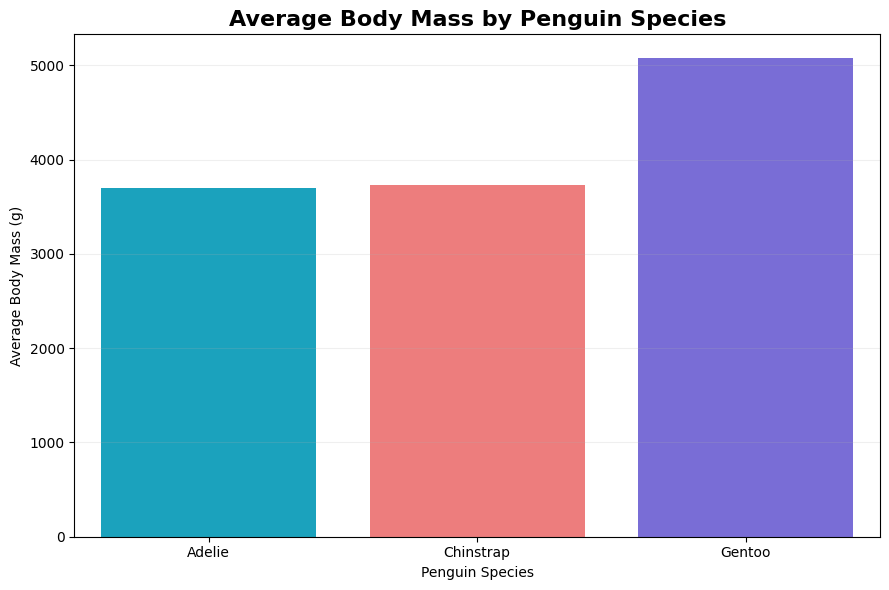

In [3]:
#TASK 1
import matplotlib.pyplot as plt

# Calculate average body mass by species
avg_mass = df.groupby('species', as_index=False)['body_mass_g'].mean()

# Create bar chart
plt.figure(figsize=(9, 6))

sns.barplot(
    data=avg_mass,
    x='species',
    y='body_mass_g',
    hue='species',
    palette=['#00B4D8', '#FF6B6B', '#6C5CE7'],
    legend=False
)

plt.title('Average Body Mass by Penguin Species', fontsize=16, fontweight='bold')
plt.xlabel('Penguin Species')
plt.ylabel('Average Body Mass (g)')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

**TASK 2**

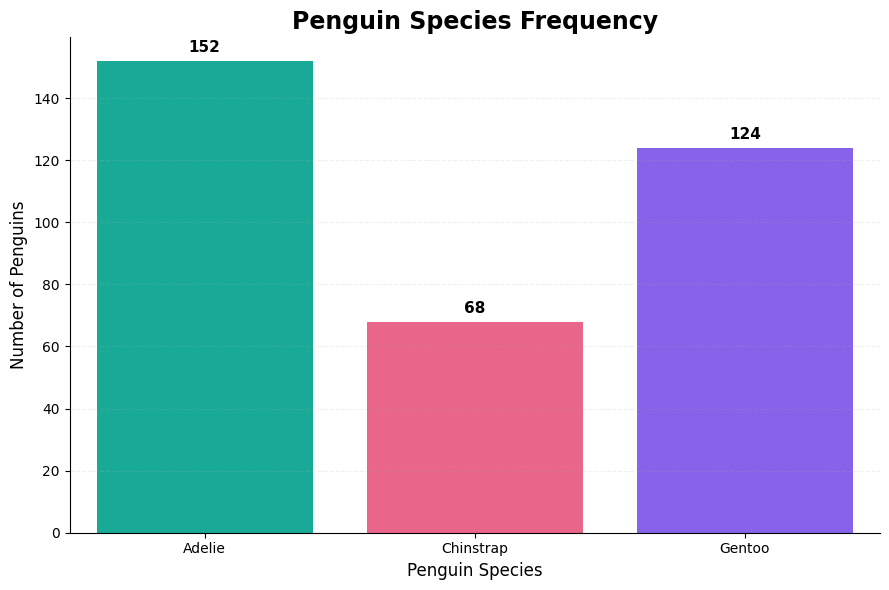

Most common category: Adelie (152 penguins)


In [4]:

# Count records by species
species_counts = df['species'].value_counts()

# Find most common species
most_common = species_counts.idxmax()
most_common_count = species_counts.max()

# Vibrant species palette
species_colors = {
    'Adelie': '#00C2A8',
    'Chinstrap': '#FF4F81',
    'Gentoo': '#7C4DFF'
}

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x='species',
    hue='species',
    palette=species_colors,
    legend=False
)

# Add values above bars
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold', padding=4)

plt.title('Penguin Species Frequency', fontsize=17, fontweight='bold')
plt.xlabel('Penguin Species', fontsize=12)
plt.ylabel('Number of Penguins', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.18)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Most common category: {most_common} ({most_common_count} penguins)")

**TASK # 3**

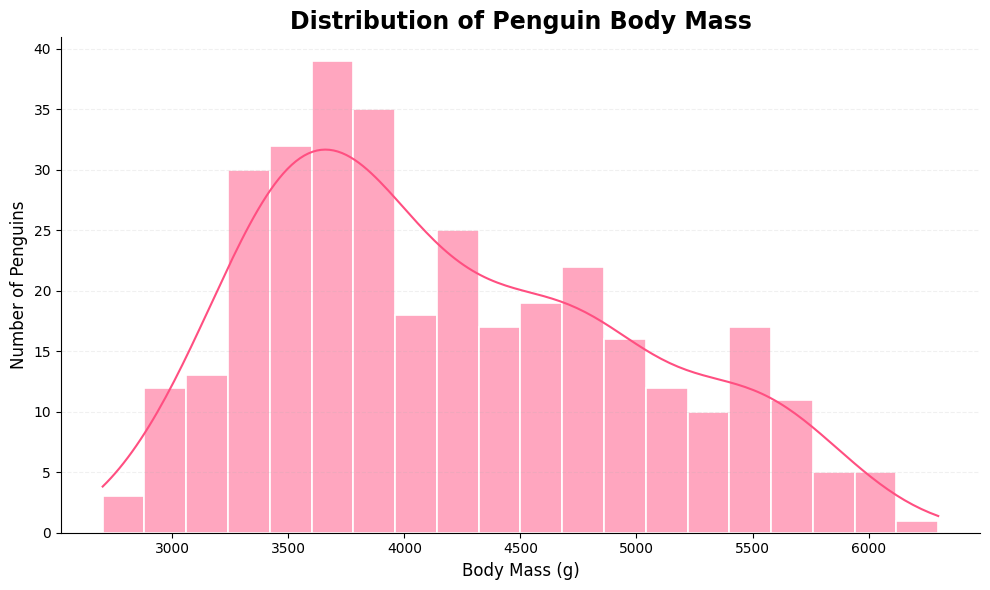

In [9]:

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='body_mass_g',
    bins=20,
    kde=True,
    color='#ff4f81',
    edgecolor='white',
    linewidth=1.2
)

plt.title('Distribution of Penguin Body Mass', fontsize=17, fontweight='bold')
plt.xlabel('Body Mass (g)', fontsize=12)
plt.ylabel('Number of Penguins', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.18)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

TASK 4

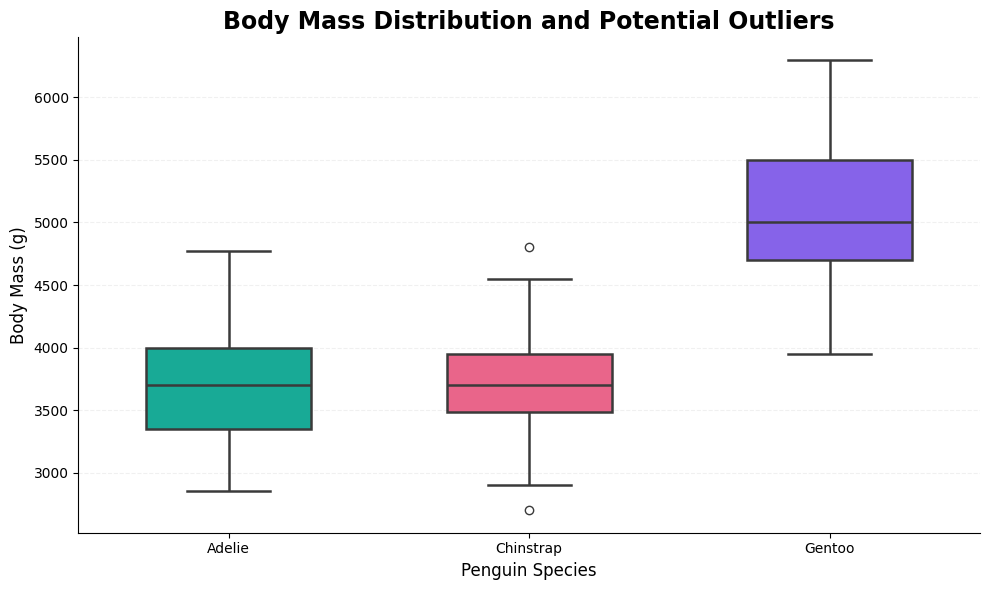

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    hue='species',
    palette=['#00C2A8', '#FF4F81', '#7C4DFF'],
    legend=False,
    width=0.55,
    linewidth=1.8,
    fliersize=6
)

plt.title('Body Mass Distribution and Potential Outliers',
          fontsize=17, fontweight='bold')

plt.xlabel('Penguin Species', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.18)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

TASK 5

In [11]:
# Calculate Q1 and Q3
Q1 = df['body_mass_g'].quantile(0.25)
Q3 = df['body_mass_g'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df['body_mass_g'] < lower) |
    (df['body_mass_g'] > upper)
]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower:.2f}")
print(f"Upper Bound: {upper:.2f}")
print(f"Number of IQR outliers: {len(outliers)}")

Q1: 3550.00
Q3: 4750.00
IQR: 1200.00
Lower Bound: 1750.00
Upper Bound: 6550.00
Number of IQR outliers: 0


TASK 6


In [12]:
from scipy import stats

# Calculate z-scores
df['zscore'] = stats.zscore(df['body_mass_g'], nan_policy='omit')

# Find observations with |z| > 3
outliers_z = df[df['zscore'].abs() > 3]

print(f"Number of Z-score outliers: {len(outliers_z)}")

Number of Z-score outliers: 0


TASK 7

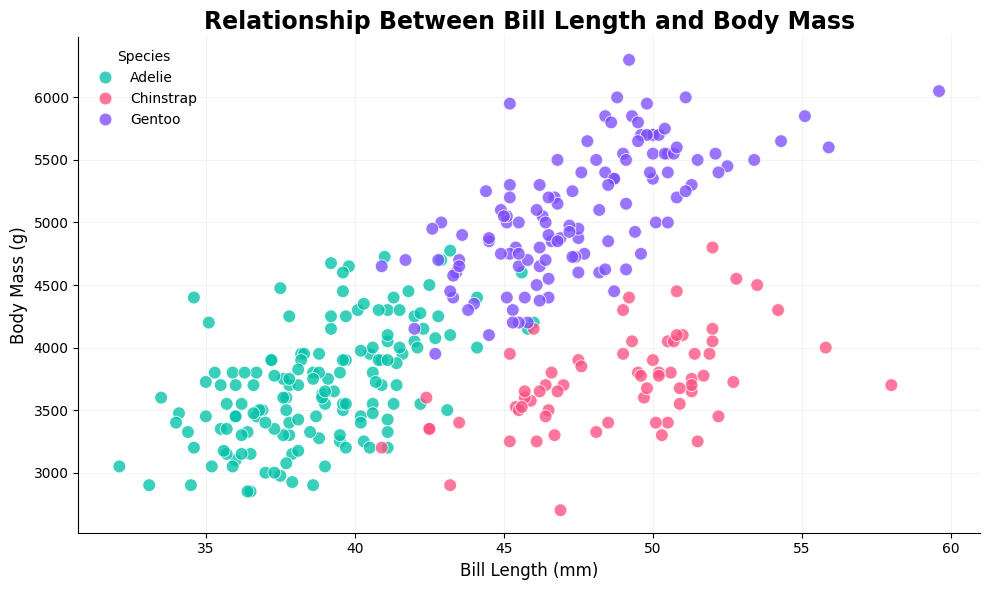

In [13]:


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species',
    palette={
        'Adelie': '#00C2A8',
        'Chinstrap': '#FF4F81',
        'Gentoo': '#7C4DFF'
    },
    s=85,
    alpha=0.78,
    edgecolor='white',
    linewidth=0.7
)

plt.title('Relationship Between Bill Length and Body Mass',
          fontsize=17, fontweight='bold')

plt.xlabel('Bill Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.legend(title='Species', frameon=False)
plt.grid(alpha=0.15)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

TASK 8

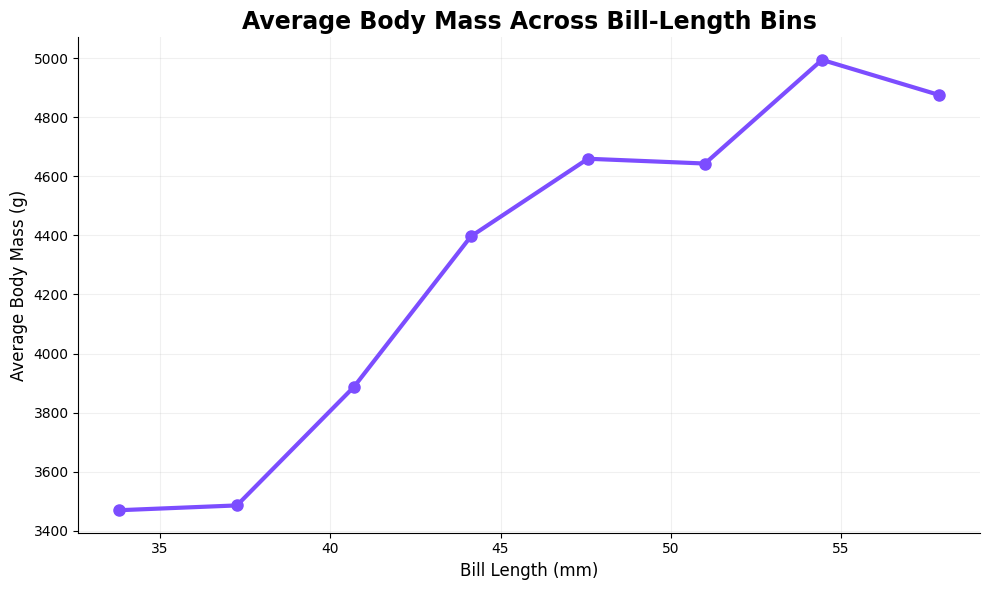

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Create ordered bill-length bins
df['bill_length_bin'] = pd.cut(
    df['bill_length_mm'],
    bins=8
)

# Calculate average body mass for each bin
trend = (
    df.groupby('bill_length_bin', observed=True)['body_mass_g']
    .mean()
    .reset_index()
)

# Use bin midpoint for the x-axis
trend['bin_midpoint'] = trend['bill_length_bin'].apply(
    lambda x: x.mid
)

plt.figure(figsize=(10, 6))

plt.plot(
    trend['bin_midpoint'],
    trend['body_mass_g'],
    marker='o',
    linewidth=3,
    markersize=8,
    color='#7C4DFF'
)

plt.title('Average Body Mass Across Bill-Length Bins',
          fontsize=17, fontweight='bold')

plt.xlabel('Bill Length (mm)', fontsize=12)
plt.ylabel('Average Body Mass (g)', fontsize=12)

plt.grid(alpha=0.18)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

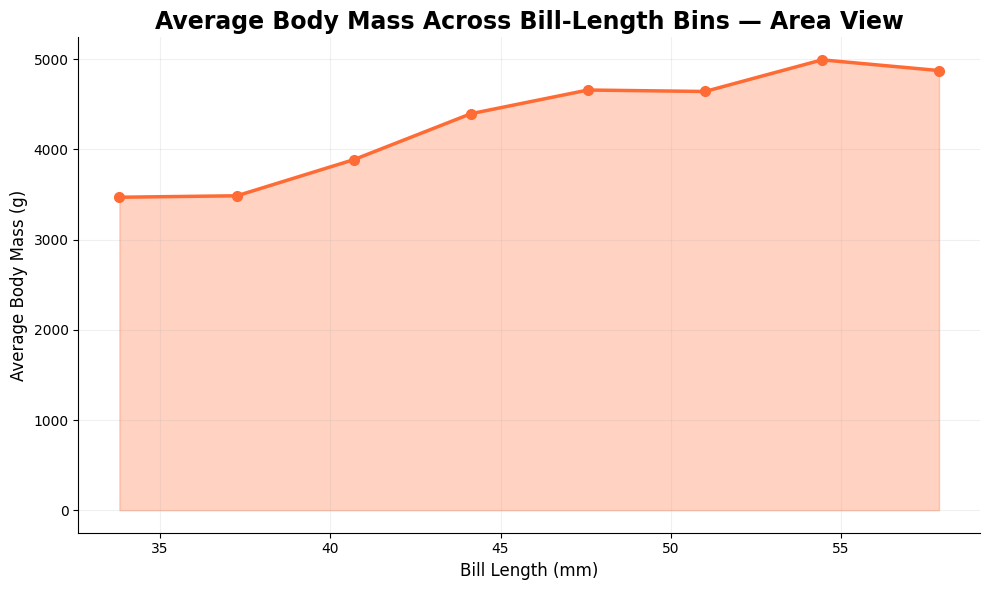

In [20]:
plt.figure(figsize=(10, 6))

plt.fill_between(
    trend['bin_midpoint'],
    trend['body_mass_g'],
    alpha=0.30,
    color='#FF6B35'
)

plt.plot(
    trend['bin_midpoint'],
    trend['body_mass_g'],
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='#FF6B35'
)

plt.title('Average Body Mass Across Bill-Length Bins — Area View',
          fontsize=17, fontweight='bold')

plt.xlabel('Bill Length (mm)', fontsize=12)
plt.ylabel('Average Body Mass (g)', fontsize=12)

plt.grid(alpha=0.18)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

tASK 9

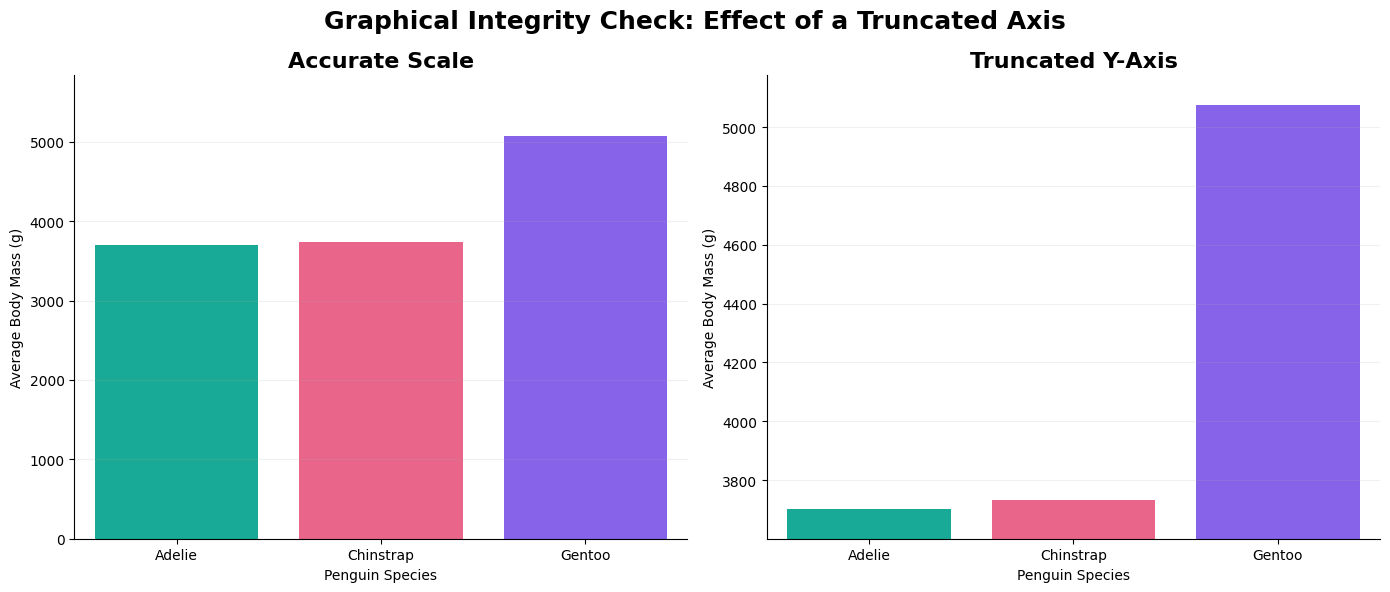

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average body mass
avg_mass = df.groupby('species', as_index=False)['body_mass_g'].mean()

species_colors = {
    'Adelie': '#00C2A8',
    'Chinstrap': '#FF4F81',
    'Gentoo': '#7C4DFF'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# Correct chart: y-axis starts at 0
# -------------------------------
sns.barplot(
    data=avg_mass,
    x='species',
    y='body_mass_g',
    hue='species',
    palette=species_colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'Accurate Scale',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_xlabel('Penguin Species')
axes[0].set_ylabel('Average Body Mass (g)')
axes[0].set_ylim(0, avg_mass['body_mass_g'].max() * 1.15)

axes[0].grid(axis='y', alpha=0.18)
axes[0].spines[['top', 'right']].set_visible(False)


# --------------------------------
# Misleading chart: truncated axis
# --------------------------------
sns.barplot(
    data=avg_mass,
    x='species',
    y='body_mass_g',
    hue='species',
    palette=species_colors,
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    'Truncated Y-Axis',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('Penguin Species')
axes[1].set_ylabel('Average Body Mass (g)')

# Deliberately start above zero
axes[1].set_ylim(
    avg_mass['body_mass_g'].min() - 100,
    avg_mass['body_mass_g'].max() + 100
)

axes[1].grid(axis='y', alpha=0.18)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Graphical Integrity Check: Effect of a Truncated Axis',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()